# Foil Matching - CCB Foils 1 & 2

This notebook matches and merges two adjacent foil images by detecting their edges and aligning them.

In [132]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd()
while not (project_root / 'pyproject.toml').exists() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [133]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from src.data.analysis import Circle
from src.data.matching import (
    find_edge_crossings, fit_edge_line, rotate_image, rotate_circle,
    rotate_edge_line, transform_edge_line_for_crop,
    crop_centered, merge_images, transform_circle_for_merge
)

## Configuration

In [134]:
# ============================================================================
# CONFIGURATION - Adjust these parameters as needed
# ============================================================================

# Data path
DATA_PATH = Path(r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_ccb\2025-12-19")

# Foil IDs to match (left and right)
LEFT_FOIL_ID = 3
RIGHT_FOIL_ID = 2

# Edge detection parameters
EDGE_THRESHOLD = 400.0          # Intensity threshold for edge detection
EDGE_X_POSITIONS = [140, 160, 180, 200, 220, 240, 260]  # X positions to sample for edge
EDGE_STRIPE_WIDTH = 10          # Width of vertical stripe to average

# Merging parameters
MERGE_MARGIN = 0               # Negative = overlap, Positive = gap (in pixels)
CROP_SIZE = 300                 # Size of cropped images before merge

# Pixel to mm conversion (MBO foils CCB experiment)
PIXEL_SIZE_MM = 0.074           # mm per pixel (74 µm)

# Visualization
VMAX = 3000                     # Max intensity for colormap
WHITE_THRESHOLD = 0.05          # Fraction of VMAX below which color is white (0-1)

# Circle Refinement Parameters (gradient-based detection)
CIRCLE_GRADIENT_HIGH = 300      # Upper threshold for gradient detection (signal starts dropping)
CIRCLE_GRADIENT_LOW = 200       # Lower threshold for gradient detection (signal has dropped)
CIRCLE_EDGE_DISTANCE_MM = 0.5   # Max distance from initial circle edge to consider points (mm)
CIRCLE_RADIUS_TOLERANCE = 0.05  # Allowed radius deviation from initial (5% = 0.05)

# Custom colormap: white (0-5%) -> green (50%) -> red (100%)
CMAP = LinearSegmentedColormap.from_list('white_green_red', [
    (0.0, (1.0, 1.0, 1.0, 1.0)),                    # 0% = white
    (WHITE_THRESHOLD, (1.0, 1.0, 1.0, 1.0)),        # WHITE_THRESHOLD% = white
    (0.5, (0.0, 1.0, 0.0, 1.0)),                    # 50% = green
    (1.0, (1.0, 0.0, 0.0, 1.0)),                    # 100% = red
])

## Load Preprocessed Data

In [135]:
# Load preprocessed data from previous notebook
with open(DATA_PATH / 'mbo_ccb_processed.pkl', 'rb') as f:
    data = pickle.load(f)

# Extract and flip images (fliplr for consistent orientation)
left_img = np.fliplr(data.data[LEFT_FOIL_ID].raw.image)
right_img = np.fliplr(data.data[RIGHT_FOIL_ID].raw.image)

# Flip circle X coordinates
left_circle = Circle(
    x=left_img.shape[1] - data.data[LEFT_FOIL_ID].circle.x,
    y=data.data[LEFT_FOIL_ID].circle.y,
    r=data.data[LEFT_FOIL_ID].circle.r
)
right_circle = Circle(
    x=right_img.shape[1] - data.data[RIGHT_FOIL_ID].circle.x,
    y=data.data[RIGHT_FOIL_ID].circle.y,
    r=data.data[RIGHT_FOIL_ID].circle.r
)

print(f"Left image shape: {left_img.shape}, circle: ({left_circle.x:.1f}, {left_circle.y:.1f})")
print(f"Right image shape: {right_img.shape}, circle: ({right_circle.x:.1f}, {right_circle.y:.1f})")

Left image shape: (424, 424), circle: (192.5, 189.5)
Right image shape: (424, 424), circle: (191.5, 191.5)


## Edge Detection and Line Fitting

In [136]:
# Find edge crossings and fit lines
left_crossings = find_edge_crossings(left_img, EDGE_X_POSITIONS, EDGE_THRESHOLD, EDGE_STRIPE_WIDTH)
right_crossings = find_edge_crossings(right_img, EDGE_X_POSITIONS, EDGE_THRESHOLD, EDGE_STRIPE_WIDTH)

left_line = fit_edge_line(left_crossings, robust=True)
right_line = fit_edge_line(right_crossings, robust=True)

print(f"Left edge slope: {left_line.slope_deg:.3f}°, {len(left_line.points)} points")
print(f"Right edge slope: {right_line.slope_deg:.3f}°, {len(right_line.points)} points")

Left edge slope: -3.656°, 7 points
Right edge slope: -6.124°, 7 points


C:\Users\grzanka\AppData\Local\Temp\ipykernel_5520\2045649950.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


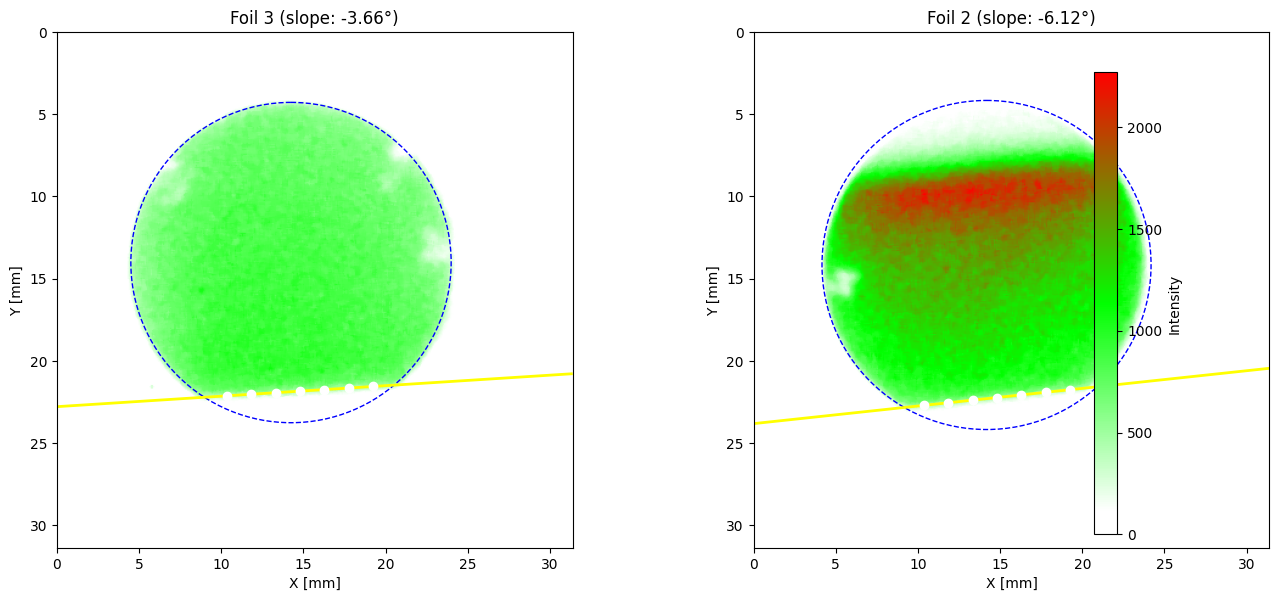

In [137]:
# Visualize original images with detected edges
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
h, w = left_img.shape

# Calculate common vmax for both images
vmax_common = max(np.nanmax(left_img), np.nanmax(right_img))
vmax_common = min(vmax_common, VMAX)  # Cap at VMAX

for ax, img, line, circle, title in [
    (axes[0], left_img, left_line, left_circle, f'Foil {LEFT_FOIL_ID}'),
    (axes[1], right_img, right_line, right_circle, f'Foil {RIGHT_FOIL_ID}')
]:
    # Create extent in mm
    extent_mm = [0, img.shape[1] * PIXEL_SIZE_MM, img.shape[0] * PIXEL_SIZE_MM, 0]
    im = ax.imshow(img, cmap=CMAP, vmin=0, vmax=vmax_common, extent=extent_mm)
    
    # Circle in mm (initial circle - blue dashed)
    ax.add_patch(plt.Circle((circle.x * PIXEL_SIZE_MM, circle.y * PIXEL_SIZE_MM), 
                            circle.r * PIXEL_SIZE_MM, color='blue', fill=False, lw=1, linestyle='--'))
    
    # Plot fitted line in mm
    xs = np.array([0, w-1])
    ys = line.slope * xs + line.intercept
    ax.plot(xs * PIXEL_SIZE_MM, ys * PIXEL_SIZE_MM, 'yellow', lw=2)
    
    # Plot edge points in mm
    for x, y in line.points:
        ax.plot(x * PIXEL_SIZE_MM, y * PIXEL_SIZE_MM, 'wo', ms=6)
    
    ax.set_title(f'{title} (slope: {line.slope_deg:.2f}°)')
    ax.set_xlabel('X [mm]')
    ax.set_ylabel('Y [mm]')

plt.colorbar(im, ax=axes, fraction=0.046, pad=0.04, label='Intensity')
plt.tight_layout()
plt.show()

## Rotate Images to Align Edges

In [138]:
# Rotate images to make edges vertical (rotate by slope + 90°)
left_rot_angle = left_line.slope_deg + 90
right_rot_angle = right_line.slope_deg - 90

left_img_rot = rotate_image(left_img, left_rot_angle)
right_img_rot = rotate_image(right_img, right_rot_angle)

# Rotate circles and edge lines to match (negative angle for coordinate transform)
left_circle_rot = rotate_circle(left_circle, left_img.shape, -left_rot_angle)
right_circle_rot = rotate_circle(right_circle, right_img.shape, -right_rot_angle)
left_line_rot = rotate_edge_line(left_line, left_img.shape, -left_rot_angle)
right_line_rot = rotate_edge_line(right_line, right_img.shape, -right_rot_angle)


print(f"Left rotated by {left_rot_angle:.2f}°, circle at ({left_circle_rot.x:.1f}, {left_circle_rot.y:.1f})")
print(f"Right rotated by {right_rot_angle:.2f}°, circle at ({right_circle_rot.x:.1f}, {right_circle_rot.y:.1f})")

Left rotated by 86.34°, circle at (188.3, 230.0)
Right rotated by -96.12°, circle at (234.6, 193.8)


## Crop and Center on Detector

In [139]:
# Crop images centered on detector circles
left_cropped, left_offset = crop_centered(left_img_rot, left_circle_rot.x, left_circle_rot.y, CROP_SIZE)
right_cropped, right_offset = crop_centered(right_img_rot, right_circle_rot.x, right_circle_rot.y, CROP_SIZE)

# Update circle and line coordinates for cropped images
left_circle_crop = Circle(
    x=left_circle_rot.x - left_offset[0],
    y=left_circle_rot.y - left_offset[1],
    r=left_circle_rot.r
)
right_circle_crop = Circle(
    x=right_circle_rot.x - right_offset[0],
    y=right_circle_rot.y - right_offset[1],
    r=right_circle_rot.r
)
left_line_crop = transform_edge_line_for_crop(left_line_rot, left_offset)
right_line_crop = transform_edge_line_for_crop(right_line_rot, right_offset)


print(f"Left cropped: {left_cropped.shape}, circle at ({left_circle_crop.x:.1f}, {left_circle_crop.y:.1f})")
print(f"Right cropped: {right_cropped.shape}, circle at ({right_circle_crop.x:.1f}, {right_circle_crop.y:.1f})")

Left cropped: (300, 300), circle at (150.3, 150.0)
Right cropped: (300, 300), circle at (150.6, 150.8)


C:\Users\grzanka\AppData\Local\Temp\ipykernel_5520\2889191756.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


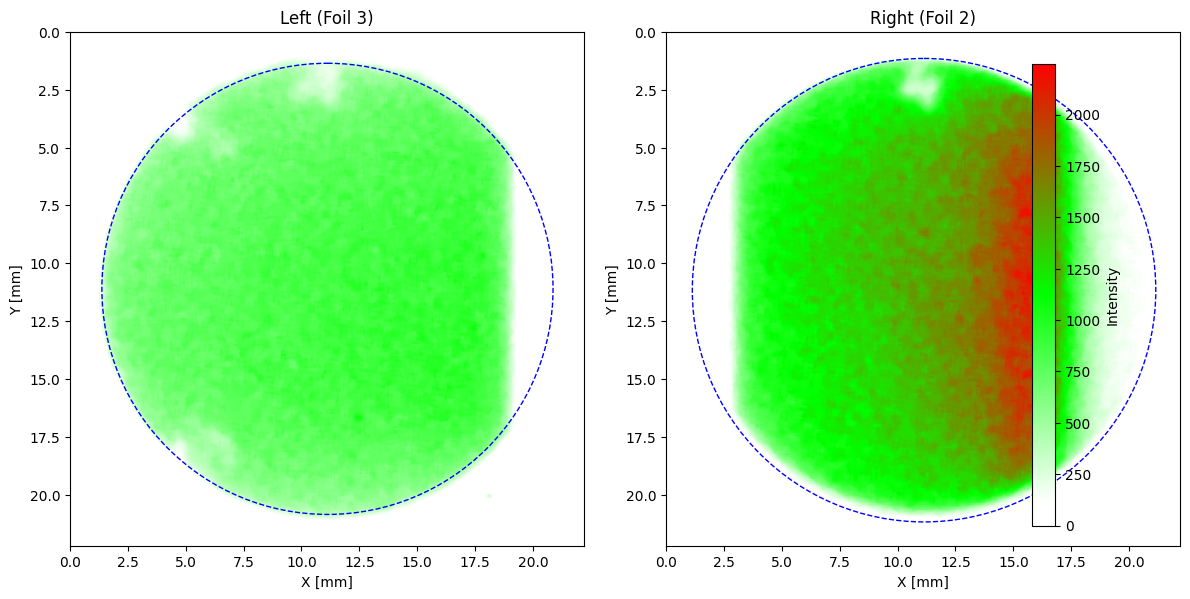

In [140]:
# Visualize cropped images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Calculate common vmax for both cropped images
vmax_crop = max(np.nanmax(left_cropped), np.nanmax(right_cropped))
vmax_crop = min(vmax_crop, VMAX)

for ax, img, circle, title in [
    (axes[0], left_cropped, left_circle_crop, f'Left (Foil {LEFT_FOIL_ID})'),
    (axes[1], right_cropped, right_circle_crop, f'Right (Foil {RIGHT_FOIL_ID})')
]:
    # Create extent in mm
    extent_mm = [0, img.shape[1] * PIXEL_SIZE_MM, img.shape[0] * PIXEL_SIZE_MM, 0]
    im = ax.imshow(img, cmap=CMAP, vmin=0, vmax=vmax_crop, extent=extent_mm)
    # Initial circle - blue dashed
    ax.add_patch(plt.Circle((circle.x * PIXEL_SIZE_MM, circle.y * PIXEL_SIZE_MM), 
                            circle.r * PIXEL_SIZE_MM, color='blue', fill=False, lw=1, linestyle='--'))
    ax.set_title(title)
    ax.set_xlabel('X [mm]')
    ax.set_ylabel('Y [mm]')

plt.colorbar(im, ax=axes, fraction=0.046, pad=0.04, label='Intensity')
plt.tight_layout()
plt.show()

## Improved Circle Detection (Gradient-Based)

Refine circle positions using gradient-based edge detection:
1. Detect intensity gradient where signal drops from HIGH to LOW threshold
2. Filter edge points within specified distance from initial circle
3. Fit new circle constrained to ±5% of initial radius

In [141]:
def find_gradient_edge_points(image, high_thresh, low_thresh):
    """
    Find edge points where intensity drops from high_thresh to low_thresh.
    Uses radial scanning from center to find transition zones.
    
    Returns: list of (x, y) edge points
    """
    h, w = image.shape
    cy, cx = h // 2, w // 2
    edge_points = []
    
    # Scan radially in multiple directions
    n_angles = 360
    for angle_idx in range(n_angles):
        angle = 2 * np.pi * angle_idx / n_angles
        
        # Scan along ray from center outward
        max_radius = min(h, w) // 2
        prev_val = None
        in_transition = False
        transition_start = None
        
        for r in range(10, max_radius):
            x = int(cx + r * np.cos(angle))
            y = int(cy + r * np.sin(angle))
            
            if 0 <= x < w and 0 <= y < h:
                val = image[y, x]
                
                if prev_val is not None:
                    # Detect start of transition zone
                    if not in_transition and prev_val > high_thresh and val <= high_thresh:
                        in_transition = True
                        transition_start = (x, y)
                    
                    # Detect end of transition - when signal drops below low threshold
                    if in_transition and val < low_thresh:
                        if transition_start is not None:
                            # Use the midpoint of the transition
                            mid_x = (transition_start[0] + x) // 2
                            mid_y = (transition_start[1] + y) // 2
                            edge_points.append((mid_x, mid_y))
                        in_transition = False
                        transition_start = None
                        break  # Found edge for this ray
                
                prev_val = val
    
    return edge_points


def filter_edge_points_near_circle(edge_points, circle, max_distance_px):
    """
    Filter edge points to only keep those within max_distance from the circle edge.
    """
    filtered = []
    for x, y in edge_points:
        # Distance from point to circle center
        dist_to_center = np.sqrt((x - circle.x)**2 + (y - circle.y)**2)
        # Distance from circle edge
        dist_to_edge = abs(dist_to_center - circle.r)
        if dist_to_edge <= max_distance_px:
            filtered.append((x, y))
    return filtered


def fit_circle_to_points(points, initial_circle, radius_tolerance):
    """
    Fit a circle to points with radius constrained within tolerance of initial.
    Uses least squares optimization.
    """
    from scipy.optimize import minimize
    
    if len(points) < 10:
        print(f"Warning: Only {len(points)} points, keeping initial circle")
        return initial_circle
    
    points_arr = np.array(points)
    x_pts, y_pts = points_arr[:, 0], points_arr[:, 1]
    
    min_r = initial_circle.r * (1 - radius_tolerance)
    max_r = initial_circle.r * (1 + radius_tolerance)
    
    def objective(params):
        cx, cy, r = params
        distances = np.sqrt((x_pts - cx)**2 + (y_pts - cy)**2)
        return np.sum((distances - r)**2)
    
    # Initial guess from initial circle
    x0 = [initial_circle.x, initial_circle.y, initial_circle.r]
    
    # Bounds: center can move freely, radius constrained
    bounds = [(None, None), (None, None), (min_r, max_r)]
    
    result = minimize(objective, x0, method='L-BFGS-B', bounds=bounds)
    
    return Circle(x=result.x[0], y=result.x[1], r=result.x[2])

Left: Found 360 gradient edge points
Left: 292 points within 0.5mm of initial circle
Right: Found 360 gradient edge points
Right: 226 points within 0.5mm of initial circle


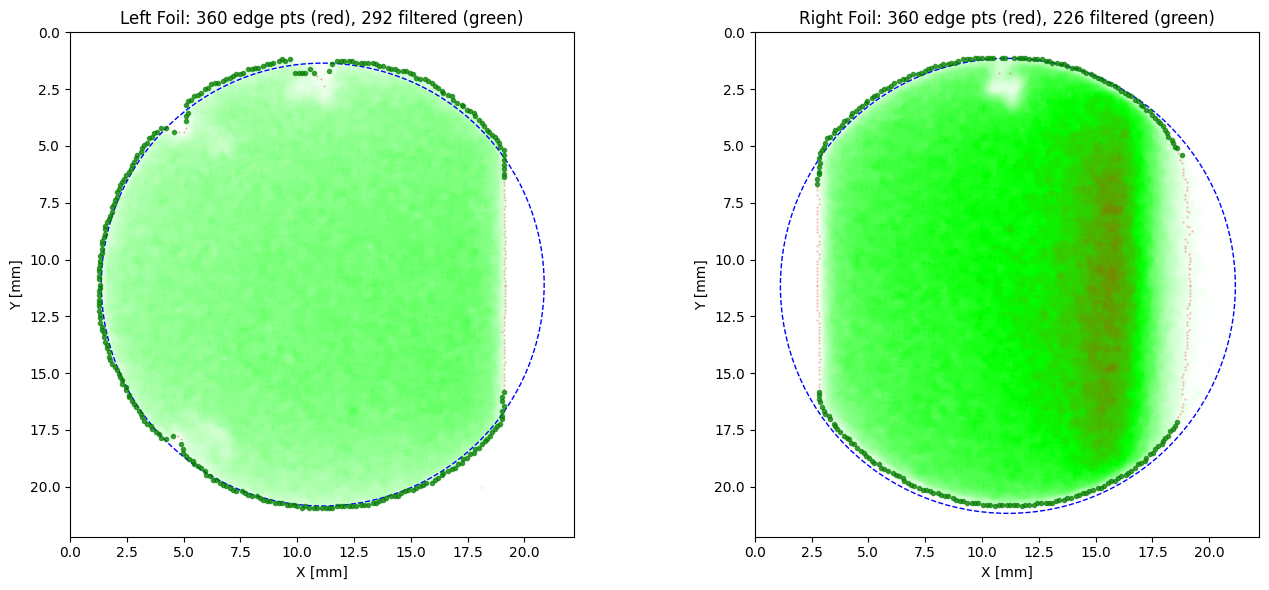

In [142]:
# Visualize gradient edge detection on both cropped images
from scipy.optimize import minimize

# Find gradient edge points
left_edge_pts = find_gradient_edge_points(left_cropped, CIRCLE_GRADIENT_HIGH, CIRCLE_GRADIENT_LOW)
print(f"Left: Found {len(left_edge_pts)} gradient edge points")

# Filter to points near initial circle
max_dist_px = CIRCLE_EDGE_DISTANCE_MM / PIXEL_SIZE_MM
left_filtered_pts = filter_edge_points_near_circle(left_edge_pts, left_circle_crop, max_dist_px)
print(f"Left: {len(left_filtered_pts)} points within {CIRCLE_EDGE_DISTANCE_MM}mm of initial circle")

# Right image - same process
right_edge_pts = find_gradient_edge_points(right_cropped, CIRCLE_GRADIENT_HIGH, CIRCLE_GRADIENT_LOW)
right_filtered_pts = filter_edge_points_near_circle(right_edge_pts, right_circle_crop, max_dist_px)
print(f"Right: Found {len(right_edge_pts)} gradient edge points")
print(f"Right: {len(right_filtered_pts)} points within {CIRCLE_EDGE_DISTANCE_MM}mm of initial circle")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left image with edge points
ax = axes[0]
extent_mm = [0, left_cropped.shape[1] * PIXEL_SIZE_MM, left_cropped.shape[0] * PIXEL_SIZE_MM, 0]
ax.imshow(left_cropped, cmap=CMAP, vmin=0, vmax=VMAX, extent=extent_mm)

# Initial circle
ax.add_patch(plt.Circle((left_circle_crop.x * PIXEL_SIZE_MM, left_circle_crop.y * PIXEL_SIZE_MM),
                        left_circle_crop.r * PIXEL_SIZE_MM, color='blue', fill=False, lw=1, linestyle='--'))

# All edge points (red)
for x, y in left_edge_pts:
    ax.plot(x * PIXEL_SIZE_MM, y * PIXEL_SIZE_MM, 'r.', ms=1, alpha=0.3)
# Filtered edge points (green)
for x, y in left_filtered_pts:
    ax.plot(x * PIXEL_SIZE_MM, y * PIXEL_SIZE_MM, 'go', ms=3, alpha=0.7)

ax.set_title(f'Left Foil: {len(left_edge_pts)} edge pts (red), {len(left_filtered_pts)} filtered (green)')
ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')

# Right image
ax = axes[1]
extent_mm = [0, right_cropped.shape[1] * PIXEL_SIZE_MM, right_cropped.shape[0] * PIXEL_SIZE_MM, 0]
ax.imshow(right_cropped, cmap=CMAP, vmin=0, vmax=VMAX, extent=extent_mm)

ax.add_patch(plt.Circle((right_circle_crop.x * PIXEL_SIZE_MM, right_circle_crop.y * PIXEL_SIZE_MM),
                        right_circle_crop.r * PIXEL_SIZE_MM, color='blue', fill=False, lw=1, linestyle='--'))

for x, y in right_edge_pts:
    ax.plot(x * PIXEL_SIZE_MM, y * PIXEL_SIZE_MM, 'r.', ms=1, alpha=0.3)
for x, y in right_filtered_pts:
    ax.plot(x * PIXEL_SIZE_MM, y * PIXEL_SIZE_MM, 'go', ms=3, alpha=0.7)

ax.set_title(f'Right Foil: {len(right_edge_pts)} edge pts (red), {len(right_filtered_pts)} filtered (green)')
ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')

plt.tight_layout()
plt.show()

In [143]:
# Fit refined circles and compare with initial circles
left_circle_refined = fit_circle_to_points(left_filtered_pts, left_circle_crop, CIRCLE_RADIUS_TOLERANCE)
right_circle_refined = fit_circle_to_points(right_filtered_pts, right_circle_crop, CIRCLE_RADIUS_TOLERANCE)

print("Circle comparison (cropped image coordinates):")
print(f"\nLeft Foil:")
print(f"  Initial:  center=({left_circle_crop.x:.2f}, {left_circle_crop.y:.2f}) px, r={left_circle_crop.r:.2f} px")
print(f"  Refined:  center=({left_circle_refined.x:.2f}, {left_circle_refined.y:.2f}) px, r={left_circle_refined.r:.2f} px")
print(f"  Center shift: ({(left_circle_refined.x - left_circle_crop.x)*PIXEL_SIZE_MM:.3f}, {(left_circle_refined.y - left_circle_crop.y)*PIXEL_SIZE_MM:.3f}) mm")
print(f"  Radius change: {(left_circle_refined.r - left_circle_crop.r)*PIXEL_SIZE_MM:.3f} mm ({100*(left_circle_refined.r/left_circle_crop.r - 1):.2f}%)")

print(f"\nRight Foil:")
print(f"  Initial:  center=({right_circle_crop.x:.2f}, {right_circle_crop.y:.2f}) px, r={right_circle_crop.r:.2f} px")
print(f"  Refined:  center=({right_circle_refined.x:.2f}, {right_circle_refined.y:.2f}) px, r={right_circle_refined.r:.2f} px")
print(f"  Center shift: ({(right_circle_refined.x - right_circle_crop.x)*PIXEL_SIZE_MM:.3f}, {(right_circle_refined.y - right_circle_crop.y)*PIXEL_SIZE_MM:.3f}) mm")
print(f"  Radius change: {(right_circle_refined.r - right_circle_crop.r)*PIXEL_SIZE_MM:.3f} mm ({100*(right_circle_refined.r/right_circle_crop.r - 1):.2f}%)")

Circle comparison (cropped image coordinates):

Left Foil:
  Initial:  center=(150.30, 150.03) px, r=131.70 px
  Refined:  center=(150.38, 149.34) px, r=133.21 px
  Center shift: (0.006, -0.050) mm
  Radius change: 0.112 mm (1.15%)

Right Foil:
  Initial:  center=(150.57, 150.80) px, r=135.30 px
  Refined:  center=(149.08, 148.15) px, r=133.28 px
  Center shift: (-0.110, -0.197) mm
  Radius change: -0.150 mm (-1.50%)


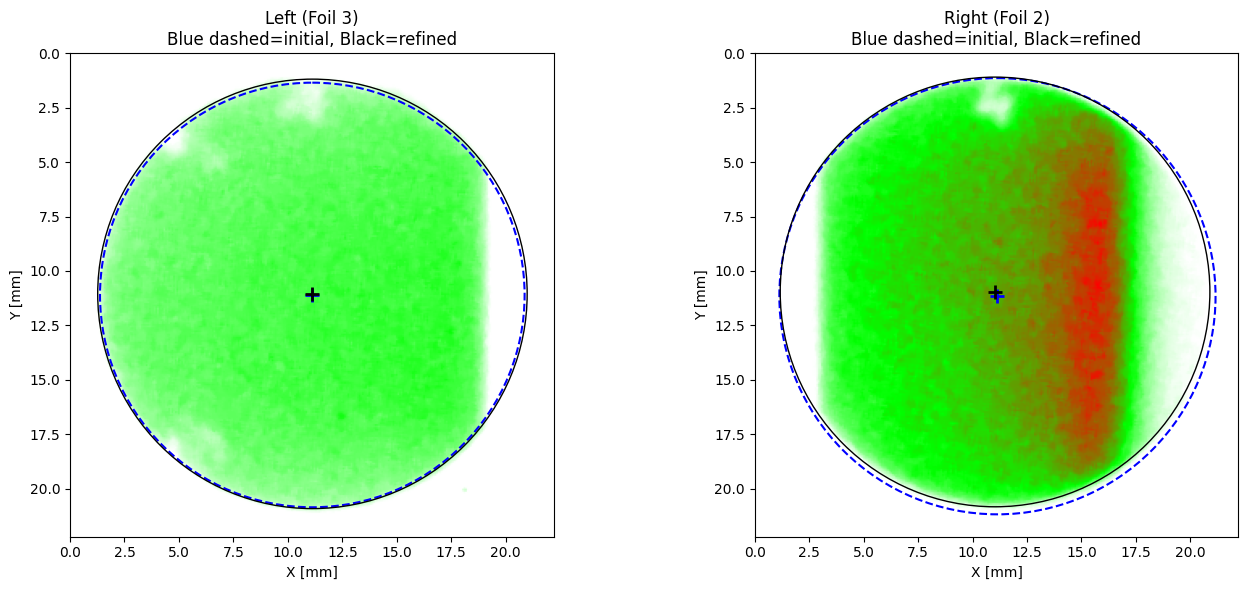

In [144]:
# Visualize initial vs refined circles
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

vmax_crop = min(max(np.nanmax(left_cropped), np.nanmax(right_cropped)), VMAX)

for ax, img, init_circle, ref_circle, title in [
    (axes[0], left_cropped, left_circle_crop, left_circle_refined, f'Left (Foil {LEFT_FOIL_ID})'),
    (axes[1], right_cropped, right_circle_crop, right_circle_refined, f'Right (Foil {RIGHT_FOIL_ID})')
]:
    extent_mm = [0, img.shape[1] * PIXEL_SIZE_MM, img.shape[0] * PIXEL_SIZE_MM, 0]
    ax.imshow(img, cmap=CMAP, vmin=0, vmax=vmax_crop, extent=extent_mm)
    
    # Initial circle (dashed blue)
    ax.add_patch(plt.Circle((init_circle.x * PIXEL_SIZE_MM, init_circle.y * PIXEL_SIZE_MM),
                            init_circle.r * PIXEL_SIZE_MM, color='blue', fill=False, lw=1.5, linestyle='--'))
    ax.plot(init_circle.x * PIXEL_SIZE_MM, init_circle.y * PIXEL_SIZE_MM, 'b+', ms=10, mew=2)
    
    # Refined circle (solid black)
    ax.add_patch(plt.Circle((ref_circle.x * PIXEL_SIZE_MM, ref_circle.y * PIXEL_SIZE_MM),
                            ref_circle.r * PIXEL_SIZE_MM, color='black', fill=False, lw=1))
    ax.plot(ref_circle.x * PIXEL_SIZE_MM, ref_circle.y * PIXEL_SIZE_MM, 'k+', ms=10, mew=2)
    
    ax.set_title(f'{title}\nBlue dashed=initial, Black=refined')
    ax.set_xlabel('X [mm]')
    ax.set_ylabel('Y [mm]')

plt.tight_layout()
plt.show()

In [145]:
# Use refined circles for merging (keep original variables unchanged)
left_circle_final = left_circle_refined
right_circle_final = right_circle_refined

print("Using refined circles for merging:")
print(f"  Left:  ({left_circle_final.x:.2f}, {left_circle_final.y:.2f}) px, r={left_circle_final.r:.2f} px")
print(f"  Right: ({right_circle_final.x:.2f}, {right_circle_final.y:.2f}) px, r={right_circle_final.r:.2f} px")

Using refined circles for merging:
  Left:  (150.38, 149.34) px, r=133.21 px
  Right: (149.08, 148.15) px, r=133.28 px


## Merge Images Using Transformed Edge Positions

In [146]:
# Get edge X positions from transformed line points (after rotation, edges are vertical)
left_edge_x = np.mean([x for x, y in left_line_crop.points])
right_edge_x = np.mean([x for x, y in right_line_crop.points])

print(f"Left edge at x={left_edge_x:.1f} (from {len(left_line_crop.points)} points)")
print(f"Right edge at x={right_edge_x:.1f} (from {len(right_line_crop.points)} points)")
print(f"Merge margin: {MERGE_MARGIN} pixels")

Left edge at x=256.3 (from 7 points)
Right edge at x=41.3 (from 7 points)
Merge margin: 0 pixels


In [147]:
# Shift images vertically to center circles at middle Y coordinate
def shift_image_vertically(image, circle, target_y):
    """
    Shift image so that circle center is at target_y.
    Pads with zeros as needed.
    Returns: shifted image, new circle with updated y coordinate
    """
    h, w = image.shape
    shift = int(round(target_y - circle.y))
    
    if shift == 0:
        return image.copy(), circle
    
    shifted = np.zeros_like(image)
    
    if shift > 0:
        # Shift down: copy top part of original to bottom part of new
        shifted[shift:, :] = image[:h-shift, :]
    else:
        # Shift up: copy bottom part of original to top part of new
        shifted[:h+shift, :] = image[-shift:, :]
    
    new_circle = Circle(x=circle.x, y=circle.y + shift, r=circle.r)
    return shifted, new_circle

# Target Y = middle of cropped image height
target_y = CROP_SIZE / 2

# Shift both images
left_shifted, left_circle_shifted = shift_image_vertically(left_cropped, left_circle_final, target_y)
right_shifted, right_circle_shifted = shift_image_vertically(right_cropped, right_circle_final, target_y)

print(f"Target Y (center): {target_y:.1f} px ({target_y * PIXEL_SIZE_MM:.2f} mm)")
print(f"Left shift: {left_circle_shifted.y - left_circle_final.y:.1f} px, new center Y: {left_circle_shifted.y:.1f} px")
print(f"Right shift: {right_circle_shifted.y - right_circle_final.y:.1f} px, new center Y: {right_circle_shifted.y:.1f} px")

Target Y (center): 150.0 px (11.10 mm)
Left shift: 1.0 px, new center Y: 150.3 px
Right shift: 2.0 px, new center Y: 150.1 px


In [148]:
# Merge shifted images
merged_image, x_offset = merge_images(left_shifted, right_shifted, left_edge_x, right_edge_x, MERGE_MARGIN)

# Transform circles to merged coordinate system
# Left circle stays at its position
left_circle_merged = left_circle_shifted
# Right circle gets x-offset applied
right_circle_merged = Circle(
    x=right_circle_shifted.x + x_offset,
    y=right_circle_shifted.y,
    r=right_circle_shifted.r
)

print(f"Merged image shape: {merged_image.shape}")
print(f"Left circle in merged: ({left_circle_merged.x:.1f}, {left_circle_merged.y:.1f}) px")
print(f"Right circle in merged: ({right_circle_merged.x:.1f}, {right_circle_merged.y:.1f}) px")

Merged image shape: (300, 515)
Left circle in merged: (150.4, 150.3) px
Right circle in merged: (364.1, 150.1) px


## Visualize Merged Image

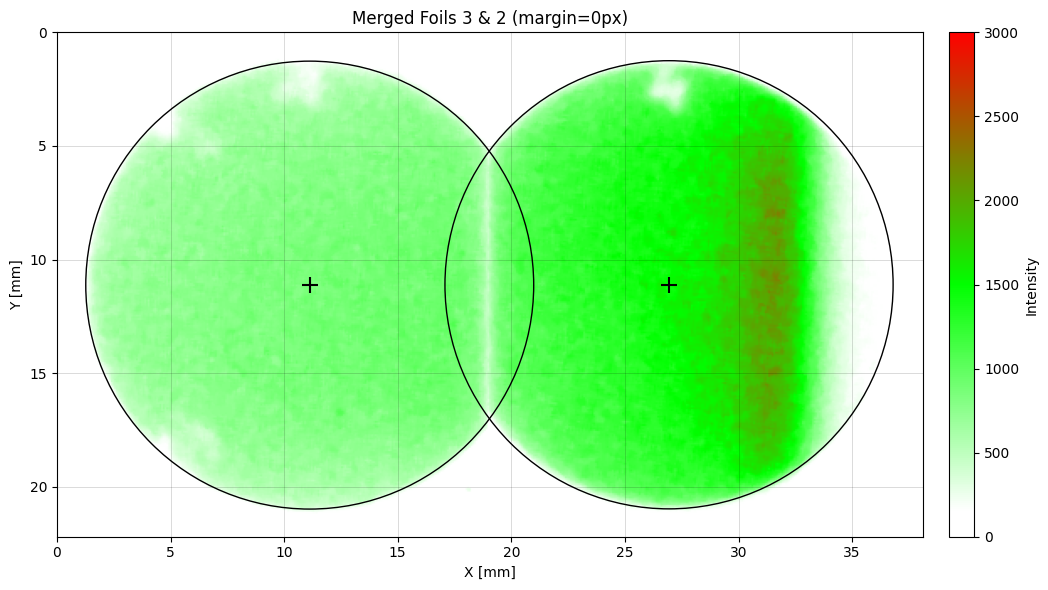

In [149]:
# Plot merged image with detector circles and centers
fig, ax = plt.subplots(figsize=(14, 6))

# Create extent in mm
h, w = merged_image.shape
extent_mm = [0, w * PIXEL_SIZE_MM, h * PIXEL_SIZE_MM, 0]

im = ax.imshow(merged_image, cmap=CMAP, vmin=0, vmax=VMAX, extent=extent_mm)

# Final/refined circles (black solid) and centers
for circle, label in [(left_circle_merged, 'Left'), (right_circle_merged, 'Right')]:
    cx_mm = circle.x * PIXEL_SIZE_MM
    cy_mm = circle.y * PIXEL_SIZE_MM
    r_mm = circle.r * PIXEL_SIZE_MM
    ax.add_patch(plt.Circle((cx_mm, cy_mm), r_mm, color='black', fill=False, lw=1))
    ax.plot(cx_mm, cy_mm, 'k+', ms=12, mew=1.5)  # Center marker

ax.set_title(f'Merged Foils {LEFT_FOIL_ID} & {RIGHT_FOIL_ID} (margin={MERGE_MARGIN}px)')
ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')

# Grid in mm (every 5 mm)
ax.set_xticks(np.arange(0, w * PIXEL_SIZE_MM + 1, 5))
ax.set_yticks(np.arange(0, h * PIXEL_SIZE_MM + 1, 5))
ax.grid(True, color='k', alpha=0.2, lw=0.5)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Intensity')
plt.tight_layout()
plt.show()

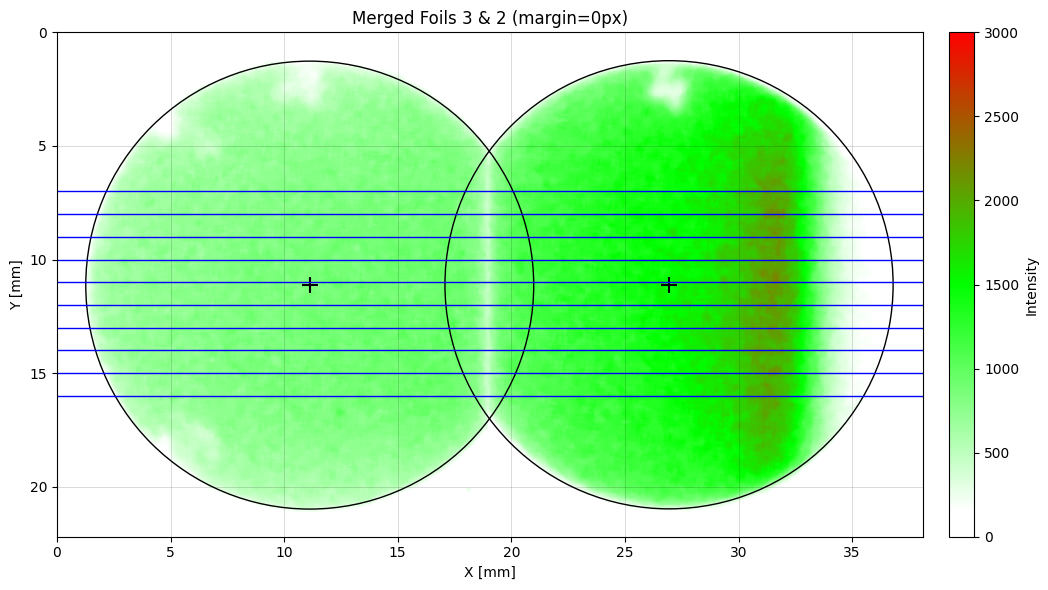

In [150]:
# Plot merged image with detector circles and centers
fig, ax = plt.subplots(figsize=(14, 6))

# Create extent in mm
h, w = merged_image.shape
extent_mm = [0, w * PIXEL_SIZE_MM, h * PIXEL_SIZE_MM, 0]

im = ax.imshow(merged_image, cmap=CMAP, vmin=0, vmax=VMAX, extent=extent_mm)

# Final/refined circles (black solid) and centers
for circle, label in [(left_circle_merged, 'Left'), (right_circle_merged, 'Right')]:
    cx_mm = circle.x * PIXEL_SIZE_MM
    cy_mm = circle.y * PIXEL_SIZE_MM
    r_mm = circle.r * PIXEL_SIZE_MM
    ax.add_patch(plt.Circle((cx_mm, cy_mm), r_mm, color='black', fill=False, lw=1))
    ax.plot(cx_mm, cy_mm, 'k+', ms=12, mew=1.5)  # Center marker

# Mark horizontal profile positions (blue lines from 10 to 18 mm, every 1 mm)
profile_y_positions_mm = np.arange(7, 17, 1)  # 10, 11, 12, ..., 18 mm
for y_mm in profile_y_positions_mm:
    ax.axhline(y=y_mm, color='blue', linewidth=1)

ax.set_title(f'Merged Foils {LEFT_FOIL_ID} & {RIGHT_FOIL_ID} (margin={MERGE_MARGIN}px)')
ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')

# Grid in mm (every 5 mm)
ax.set_xticks(np.arange(0, w * PIXEL_SIZE_MM + 1, 5))
ax.set_yticks(np.arange(0, h * PIXEL_SIZE_MM + 1, 5))
ax.grid(True, color='k', alpha=0.2, lw=0.5)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Intensity')
plt.tight_layout()
plt.show()

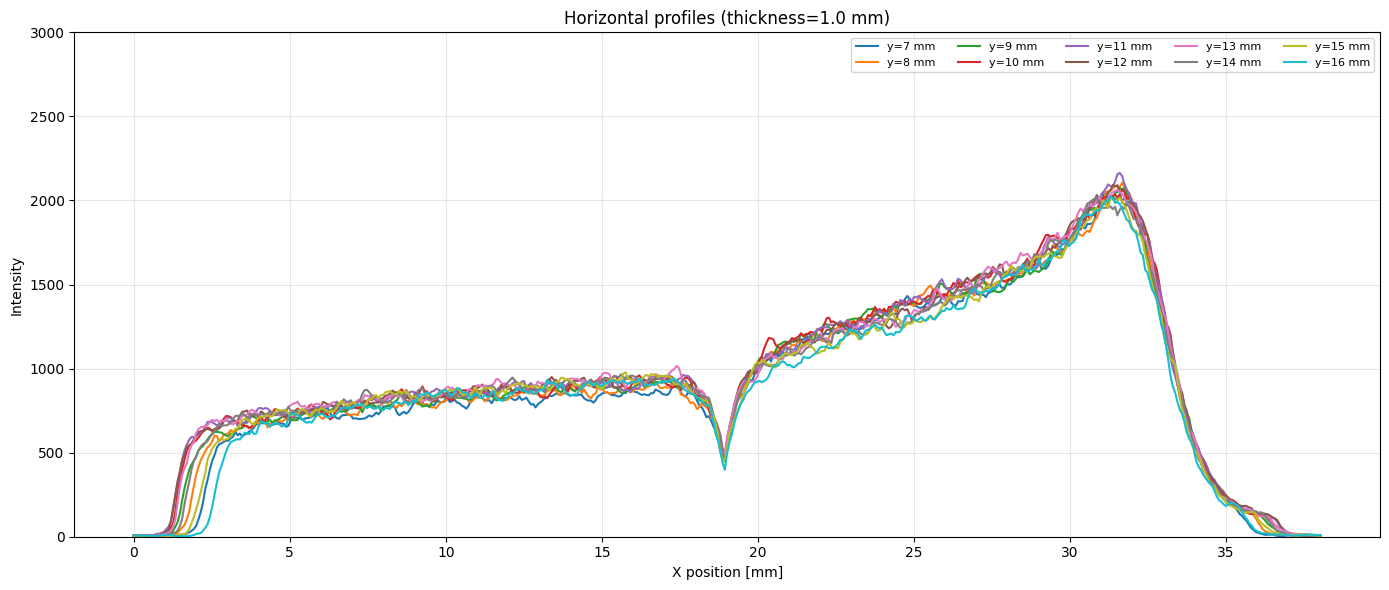

In [151]:
# Horizontal profiles at different y positions
fig, ax = plt.subplots(figsize=(14, 6))

thickness_mm = 1.0  # 1 mm thickness
thickness_px = int(thickness_mm / PIXEL_SIZE_MM)

# X axis in mm
x_mm = np.arange(merged_image.shape[1]) * PIXEL_SIZE_MM

for y_mm in profile_y_positions_mm:
    y_px = int(y_mm / PIXEL_SIZE_MM)
    y0 = max(0, y_px - thickness_px // 2)
    y1 = min(merged_image.shape[0], y_px + thickness_px // 2)
    profile = np.nanmean(merged_image[y0:y1, :].astype(float), axis=0)
    ax.plot(x_mm, profile, label=f'y={y_mm:.0f} mm')

ax.set(xlabel='X position [mm]', ylabel='Intensity', ylim=(0, VMAX),
       title=f'Horizontal profiles (thickness={thickness_mm:.1f} mm)')
ax.legend(ncols=5, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Profile Y range: 9-13 mm
Section 1 X range: 10-16 mm
Section 2 X range: 21-27 mm
Fitting function: parabola
Shift range: -5 to 5 mm (500 steps)


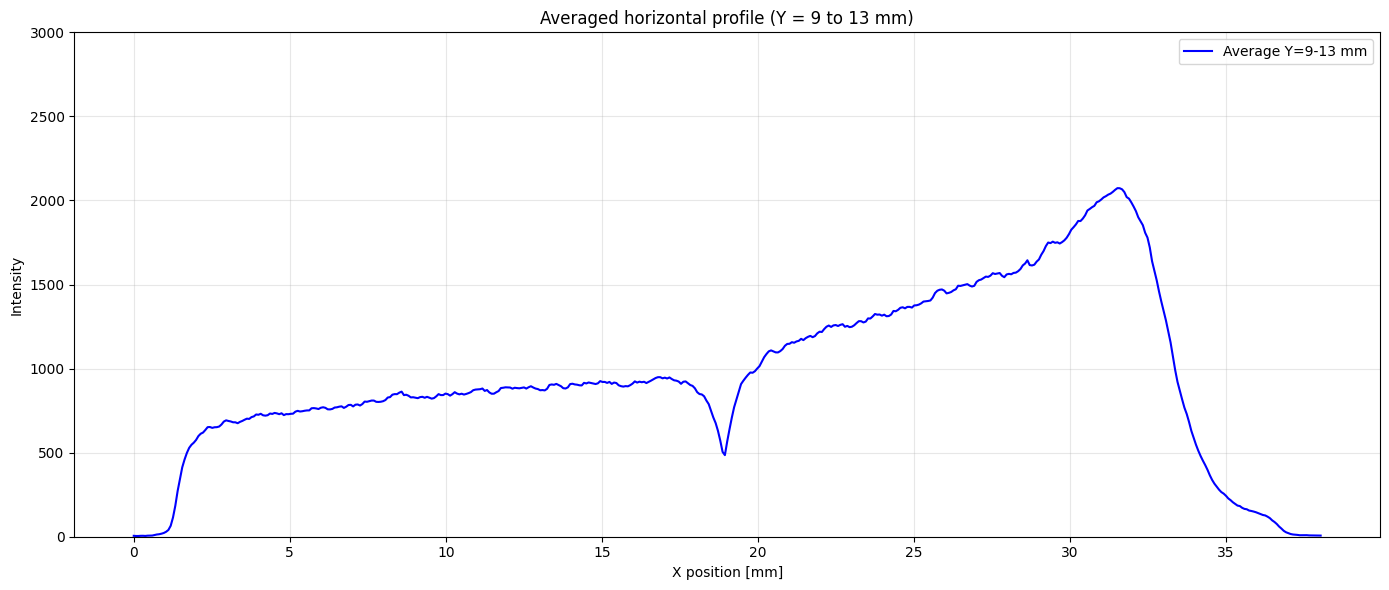

In [152]:
# Define Y and X ranges for profile analysis (used in subsequent cells)
# Y range for averaging
PROFILE_Y_MIN_MM = 9
PROFILE_Y_MAX_MM = 13
PROFILE_Y_MIN_PX = int(PROFILE_Y_MIN_MM / PIXEL_SIZE_MM)
PROFILE_Y_MAX_PX = int(PROFILE_Y_MAX_MM / PIXEL_SIZE_MM)

# X ranges for two sections
SECTION1_X_MIN, SECTION1_X_MAX = 10, 16   # Section 1: X = 7mm to 16mm
SECTION2_X_MIN, SECTION2_X_MAX = 21, 27  # Section 2: X = 21mm to 27mm

# Smoothing parameter
SMOOTHING_SIGMA = 4  # pixels

# ============================================================================
# FITTING FUNCTION CONFIGURATION
# Uncomment ONE of the following lines to select the fitting function:
# ============================================================================

# FIT_TYPE = 'spline'      # Smoothing spline (flexible, good for complex shapes)
#FIT_TYPE = 'linear'      # Straight line (y = ax + b)
FIT_TYPE = 'parabola'    # 2nd degree polynomial (y = ax² + bx + c)
#FIT_TYPE = 'poly3'       # 3rd degree polynomial (y = ax³ + bx² + cx + d)
# FIT_TYPE = 'exponential' # Exponential decay (y = a * exp(-b*x) + c)

# Spline smoothing factor (only used when FIT_TYPE = 'spline')
SPLINE_SMOOTHING = 100  # multiplied by number of points

# Shift optimization range [mm]
SHIFT_MIN = -5
SHIFT_MAX = 5
SHIFT_STEPS = 500

print(f"Profile Y range: {PROFILE_Y_MIN_MM}-{PROFILE_Y_MAX_MM} mm")
print(f"Section 1 X range: {SECTION1_X_MIN}-{SECTION1_X_MAX} mm")
print(f"Section 2 X range: {SECTION2_X_MIN}-{SECTION2_X_MAX} mm")
print(f"Fitting function: {FIT_TYPE}")
print(f"Shift range: {SHIFT_MIN} to {SHIFT_MAX} mm ({SHIFT_STEPS} steps)")

# Single averaged profile
fig, ax = plt.subplots(figsize=(14, 6))

# X axis in mm
x_mm = np.arange(merged_image.shape[1]) * PIXEL_SIZE_MM

# Calculate averaged profile
profile = np.nanmean(merged_image[PROFILE_Y_MIN_PX:PROFILE_Y_MAX_PX, :].astype(float), axis=0)
ax.plot(x_mm, profile, 'b-', lw=1.5, label=f'Average Y={PROFILE_Y_MIN_MM}-{PROFILE_Y_MAX_MM} mm')

ax.set(xlabel='X position [mm]', ylabel='Intensity', ylim=(0, VMAX),
       title=f'Averaged horizontal profile (Y = {PROFILE_Y_MIN_MM} to {PROFILE_Y_MAX_MM} mm)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

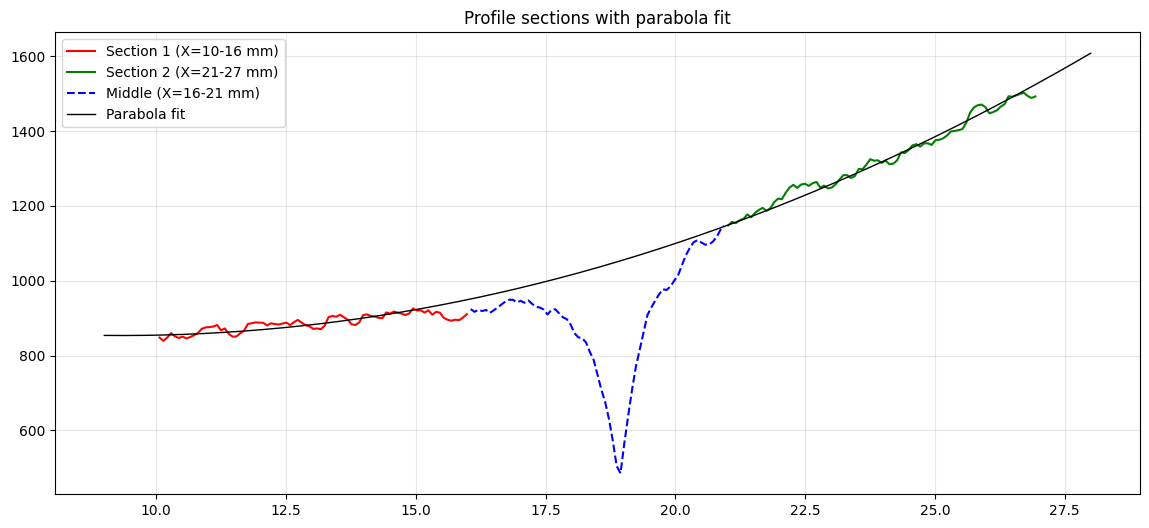

In [153]:
# Extract two sections and fit the selected function
from scipy.interpolate import UnivariateSpline
from scipy.optimize import curve_fit

fig, ax = plt.subplots(figsize=(14, 6))

# Use the averaged profile (Y range defined above)
x_mm = np.arange(merged_image.shape[1]) * PIXEL_SIZE_MM
profile = np.nanmean(merged_image[PROFILE_Y_MIN_PX:PROFILE_Y_MAX_PX, :].astype(float), axis=0)

# Extract section 1
mask1 = (x_mm >= SECTION1_X_MIN) & (x_mm <= SECTION1_X_MAX)
x_section1 = x_mm[mask1]
profile_section1 = profile[mask1]

# Extract section 2
mask2 = (x_mm >= SECTION2_X_MIN) & (x_mm <= SECTION2_X_MAX)
x_section2 = x_mm[mask2]
profile_section2 = profile[mask2]

# Plot the two sections
ax.plot(x_section1, profile_section1, 'r-', lw=1.5, label=f'Section 1 (X={SECTION1_X_MIN}-{SECTION1_X_MAX} mm)')
ax.plot(x_section2, profile_section2, 'g-', lw=1.5, label=f'Section 2 (X={SECTION2_X_MIN}-{SECTION2_X_MAX} mm)')

# Plot middle section (between sections) as dashed blue
mask_middle = (x_mm > SECTION1_X_MAX) & (x_mm < SECTION2_X_MIN)
ax.plot(x_mm[mask_middle], profile[mask_middle], 'b--', lw=1.5, label=f'Middle (X={SECTION1_X_MAX}-{SECTION2_X_MIN} mm)')

# Combine both sections for fitting
x_combined = np.concatenate([x_section1, x_section2])
profile_combined = np.concatenate([profile_section1, profile_section2])

# Sort by x for fitting
sort_idx = np.argsort(x_combined)
x_combined = x_combined[sort_idx]
profile_combined = profile_combined[sort_idx]

# Define exponential function for fitting
def exponential_func(x, a, b, c):
    return a * np.exp(-b * x) + c

# Fit based on selected type
if FIT_TYPE == 'spline':
    fit_obj = UnivariateSpline(x_combined, profile_combined, s=len(x_combined) * SPLINE_SMOOTHING)
    fit_func = fit_obj
    fit_label = 'Spline fit'
elif FIT_TYPE == 'linear':
    coeffs = np.polyfit(x_combined, profile_combined, 1)
    fit_func = np.poly1d(coeffs)
    fit_label = f'Linear fit: {coeffs[0]:.1f}x + {coeffs[1]:.1f}'
elif FIT_TYPE == 'parabola':
    coeffs = np.polyfit(x_combined, profile_combined, 2)
    fit_func = np.poly1d(coeffs)
    fit_label = 'Parabola fit'
elif FIT_TYPE == 'poly3':
    coeffs = np.polyfit(x_combined, profile_combined, 3)
    fit_func = np.poly1d(coeffs)
    fit_label = '3rd degree polynomial fit'
elif FIT_TYPE == 'exponential':
    try:
        p0 = [profile_combined.max() - profile_combined.min(), 0.1, profile_combined.min()]
        popt, _ = curve_fit(exponential_func, x_combined, profile_combined, p0=p0, maxfev=5000)
        fit_func = lambda x, popt=popt: exponential_func(x, *popt)
        fit_label = f'Exponential fit: {popt[0]:.1f}·exp(-{popt[1]:.3f}x) + {popt[2]:.1f}'
    except RuntimeError:
        print("Warning: Exponential fit failed, using poly3")
        coeffs = np.polyfit(x_combined, profile_combined, 3)
        fit_func = np.poly1d(coeffs)
        fit_label = '3rd degree polynomial fit (fallback)'

x_fit = np.linspace(SECTION1_X_MIN-1, SECTION2_X_MAX+1, 500)
y_fit = fit_func(x_fit)

# Plot fit
ax.plot(x_fit, y_fit, 'k-', lw=1, label=fit_label)

ax.set_title(f'Profile sections with {FIT_TYPE} fit')
ax.legend()
ax.grid(True, alpha=0.3)

Applied Gaussian smoothing with sigma=4 px (0.30 mm)
Fitting with: parabola


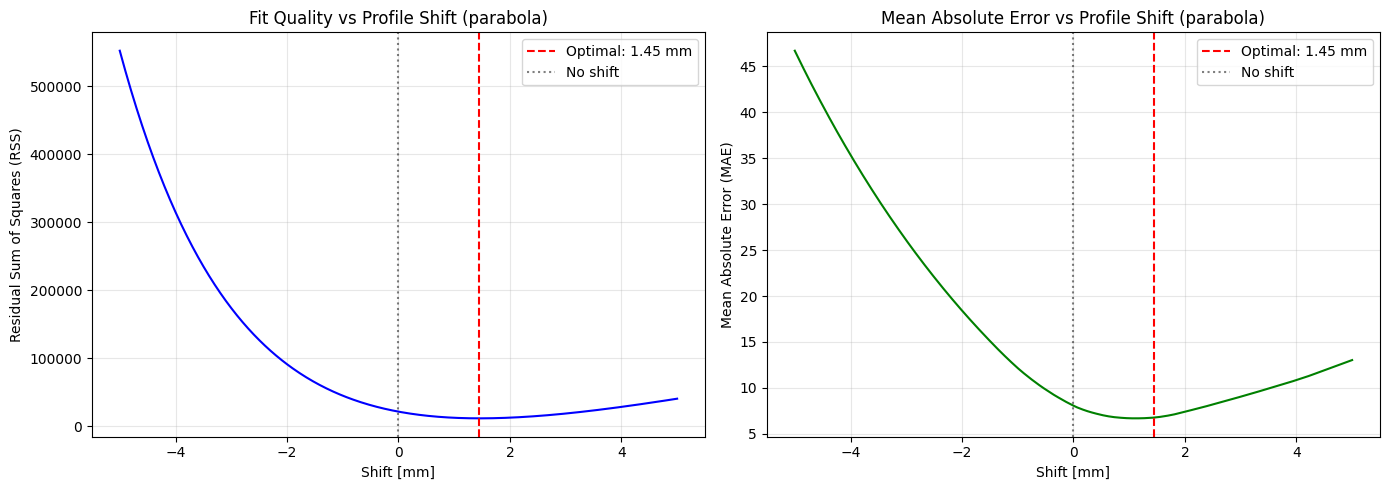


Optimization Results (parabola):
  Optimal shift: 1.45 mm (negative = profiles moved closer)
  Baseline RSS (no shift): 21669.54
  Optimal RSS: 11648.17
  RSS improvement: 46.2%


In [154]:
# Optimize profile alignment by testing different shift values
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit

# Use the averaged profile (Y range defined above)
x_mm = np.arange(merged_image.shape[1]) * PIXEL_SIZE_MM
profile_raw = np.nanmean(merged_image[PROFILE_Y_MIN_PX:PROFILE_Y_MAX_PX, :].astype(float), axis=0)

# Apply Gaussian smoothing before fitting
profile = gaussian_filter1d(profile_raw, sigma=SMOOTHING_SIGMA)
print(f"Applied Gaussian smoothing with sigma={SMOOTHING_SIGMA} px ({SMOOTHING_SIGMA * PIXEL_SIZE_MM:.2f} mm)")

# Extract original sections
mask1 = (x_mm >= SECTION1_X_MIN) & (x_mm <= SECTION1_X_MAX)
x_section1 = x_mm[mask1]
profile_section1 = profile[mask1]

mask2 = (x_mm >= SECTION2_X_MIN) & (x_mm <= SECTION2_X_MAX)
x_section2_orig = x_mm[mask2]
profile_section2 = profile[mask2]

# Define fitting functions
def exponential_func(x, a, b, c):
    """Exponential decay: y = a * exp(-b*x) + c"""
    return a * np.exp(-b * x) + c

def fit_and_evaluate(x1, y1, x2, y2, shift, fit_type=FIT_TYPE):
    """
    Shift section 2 by 'shift' mm and fit the selected function to combined data.
    
    Parameters:
    -----------
    fit_type : str
        'spline' - Smoothing spline
        'linear' - Straight line (degree 1 polynomial)
        'parabola' - 2nd degree polynomial
        'poly3' - 3rd degree polynomial
        'exponential' - Exponential decay
    
    Returns: fit_func (callable), residual sum of squares, mean absolute error, x2_shifted
    """
    x2_shifted = x2 + shift
    
    # Combine both sections
    x_combined = np.concatenate([x1, x2_shifted])
    y_combined = np.concatenate([y1, y2])
    
    # Sort by x
    sort_idx = np.argsort(x_combined)
    x_combined = x_combined[sort_idx]
    y_combined = y_combined[sort_idx]
    
    # Fit based on selected type
    if fit_type == 'spline':
        fit_obj = UnivariateSpline(x_combined, y_combined, s=len(x_combined) * SPLINE_SMOOTHING)
        fit_func = fit_obj
    elif fit_type == 'linear':
        coeffs = np.polyfit(x_combined, y_combined, 1)
        fit_func = np.poly1d(coeffs)
    elif fit_type == 'parabola':
        coeffs = np.polyfit(x_combined, y_combined, 2)
        fit_func = np.poly1d(coeffs)
    elif fit_type == 'poly3':
        coeffs = np.polyfit(x_combined, y_combined, 3)
        fit_func = np.poly1d(coeffs)
    elif fit_type == 'exponential':
        try:
            # Initial guess: amplitude, decay rate, offset
            p0 = [y_combined.max() - y_combined.min(), 0.1, y_combined.min()]
            popt, _ = curve_fit(exponential_func, x_combined, y_combined, p0=p0, maxfev=5000)
            fit_func = lambda x, popt=popt: exponential_func(x, *popt)
        except RuntimeError:
            # If exponential fit fails, fall back to polynomial
            print(f"Warning: Exponential fit failed for shift={shift:.2f}, using poly3")
            coeffs = np.polyfit(x_combined, y_combined, 3)
            fit_func = np.poly1d(coeffs)
    else:
        raise ValueError(f"Unknown fit_type: {fit_type}")
    
    # Calculate residuals
    y_pred = fit_func(x_combined)
    residuals = y_combined - y_pred
    rss = np.sum(residuals**2)
    mae = np.mean(np.abs(residuals))
    
    return fit_func, rss, mae, x2_shifted

# Test shift values (range configured above)
shift_values = np.linspace(SHIFT_MIN, SHIFT_MAX, SHIFT_STEPS)
results = []

print(f"Fitting with: {FIT_TYPE}")
for shift in shift_values:
    fit_func, rss, mae, _ = fit_and_evaluate(x_section1, profile_section1, 
                                              x_section2_orig, profile_section2, shift)
    results.append({'shift': shift, 'rss': rss, 'mae': mae})

# Convert to arrays for plotting
shifts = np.array([r['shift'] for r in results])
rss_values = np.array([r['rss'] for r in results])
mae_values = np.array([r['mae'] for r in results])

# Find optimal shift (minimum RSS)
optimal_idx = np.argmin(rss_values)
optimal_shift = shifts[optimal_idx]
optimal_rss = rss_values[optimal_idx]

# Get baseline (no shift) values
baseline_idx = np.argmin(np.abs(shifts))
baseline_rss = rss_values[baseline_idx]

# Plot fit quality vs shift
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(shifts, rss_values, 'b-', lw=1.5)
ax1.axvline(x=optimal_shift, color='r', linestyle='--', label=f'Optimal: {optimal_shift:.2f} mm')
ax1.axvline(x=0, color='k', linestyle=':', alpha=0.5, label='No shift')
ax1.set(xlabel='Shift [mm]', ylabel='Residual Sum of Squares (RSS)',
        title=f'Fit Quality vs Profile Shift ({FIT_TYPE})')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(shifts, mae_values, 'g-', lw=1.5)
ax2.axvline(x=optimal_shift, color='r', linestyle='--', label=f'Optimal: {optimal_shift:.2f} mm')
ax2.axvline(x=0, color='k', linestyle=':', alpha=0.5, label='No shift')
ax2.set(xlabel='Shift [mm]', ylabel='Mean Absolute Error (MAE)',
        title=f'Mean Absolute Error vs Profile Shift ({FIT_TYPE})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOptimization Results ({FIT_TYPE}):")
print(f"  Optimal shift: {optimal_shift:.2f} mm (negative = profiles moved closer)")
print(f"  Baseline RSS (no shift): {baseline_rss:.2f}")
print(f"  Optimal RSS: {optimal_rss:.2f}")
print(f"  RSS improvement: {(baseline_rss - optimal_rss) / baseline_rss * 100:.1f}%")

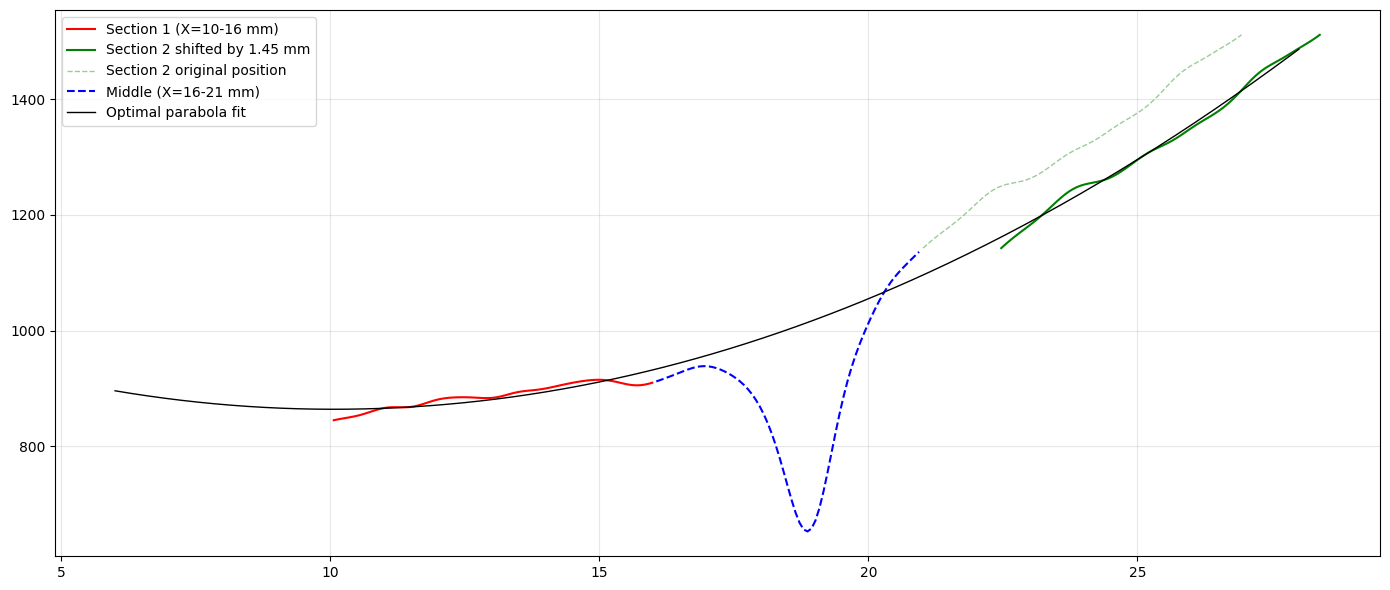


Summary (parabola fit):
  Section 2 was shifted by 1.45 mm
  (profiles moved 1.45 mm FURTHER apart)
    MAE: 8.10 -> 6.77 (16.3% reduction)

  Fit quality improvement:
    RSS: 21669.54 -> 11648.17 (46.2% reduction)


In [155]:
# Final plot with optimally shifted profiles
fig, ax = plt.subplots(figsize=(14, 6))

# Get the optimal fit
fit_func_opt, rss_opt, mae_opt, x_section2_shifted = fit_and_evaluate(
    x_section1, profile_section1, x_section2_orig, profile_section2, optimal_shift)

# Plot section 1 (unchanged, red)
ax.plot(x_section1, profile_section1, 'r-', lw=1.5, 
        label=f'Section 1 (X={SECTION1_X_MIN}-{SECTION1_X_MAX} mm)')

# Plot section 2 shifted (green)
ax.plot(x_section2_shifted, profile_section2, 'g-', lw=1.5, 
        label=f'Section 2 shifted by {optimal_shift:.2f} mm')

# Plot original section 2 position (dashed, for reference)
ax.plot(x_section2_orig, profile_section2, 'g--', lw=1, alpha=0.4, 
        label='Section 2 original position')

# Plot middle section (between sections) as dashed blue
mask_middle = (x_mm > SECTION1_X_MAX) & (x_mm < SECTION2_X_MIN)
ax.plot(x_mm[mask_middle], profile[mask_middle], 'b--', lw=1.5, label=f'Middle (X={SECTION1_X_MAX}-{SECTION2_X_MIN} mm)')

# Generate and plot optimal fit
x_fit = np.linspace(6, 28, 500)
y_fit = fit_func_opt(x_fit)
ax.plot(x_fit, y_fit, 'k-', lw=1, label=f'Optimal {FIT_TYPE} fit')

# ax.set(xlabel='X position [mm]', ylabel='Intensity', ylim=(0, VMAX),
#        title=f'Optimized Profile Alignment (shift = {optimal_shift:.2f} mm, RSS improved by {(baseline_rss - optimal_rss) / baseline_rss * 100:.1f}%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary ({FIT_TYPE} fit):")
print(f"  Section 2 was shifted by {optimal_shift:.2f} mm")
if optimal_shift < 0:
    print(f"  (profiles moved {abs(optimal_shift):.2f} mm CLOSER together)")
else:
    print(f"  (profiles moved {abs(optimal_shift):.2f} mm FURTHER apart)")
    print(f"    MAE: {mae_values[baseline_idx]:.2f} -> {mae_opt:.2f} ({(mae_values[baseline_idx] - mae_opt) / mae_values[baseline_idx] * 100:.1f}% reduction)")

print(f"\n  Fit quality improvement:")
print(f"    RSS: {baseline_rss:.2f} -> {optimal_rss:.2f} ({(baseline_rss - optimal_rss) / baseline_rss * 100:.1f}% reduction)")

In [156]:
# Re-merge images using optimized distance
# optimal_shift < 0 means profiles need to move closer → negative MERGE_MARGIN (overlap)
# optimal_shift > 0 means profiles need to move further → positive MERGE_MARGIN (gap)
OPTIMIZED_MERGE_MARGIN = int(round(optimal_shift / PIXEL_SIZE_MM))

print(f"Original MERGE_MARGIN: {MERGE_MARGIN} px")
print(f"Optimal shift: {optimal_shift:.3f} mm = {optimal_shift / PIXEL_SIZE_MM:.1f} px")
print(f"Optimized MERGE_MARGIN: {OPTIMIZED_MERGE_MARGIN} px")

# Re-merge with optimized margin
merged_image_opt, x_offset_opt = merge_images(left_shifted, right_shifted, left_edge_x, right_edge_x, OPTIMIZED_MERGE_MARGIN)

# Transform circles to new merged coordinate system
left_circle_merged_opt = left_circle_shifted
right_circle_merged_opt = Circle(
    x=right_circle_shifted.x + x_offset_opt,
    y=right_circle_shifted.y,
    r=right_circle_shifted.r
)

print(f"\nOptimized merged image shape: {merged_image_opt.shape}")
print(f"Left circle in merged: ({left_circle_merged_opt.x:.1f}, {left_circle_merged_opt.y:.1f}) px")
print(f"Right circle in merged: ({right_circle_merged_opt.x:.1f}, {right_circle_merged_opt.y:.1f}) px")

Original MERGE_MARGIN: 0 px
Optimal shift: 1.453 mm = 19.6 px
Optimized MERGE_MARGIN: 20 px

Optimized merged image shape: (300, 555)
Left circle in merged: (150.4, 150.3) px
Right circle in merged: (404.1, 150.1) px


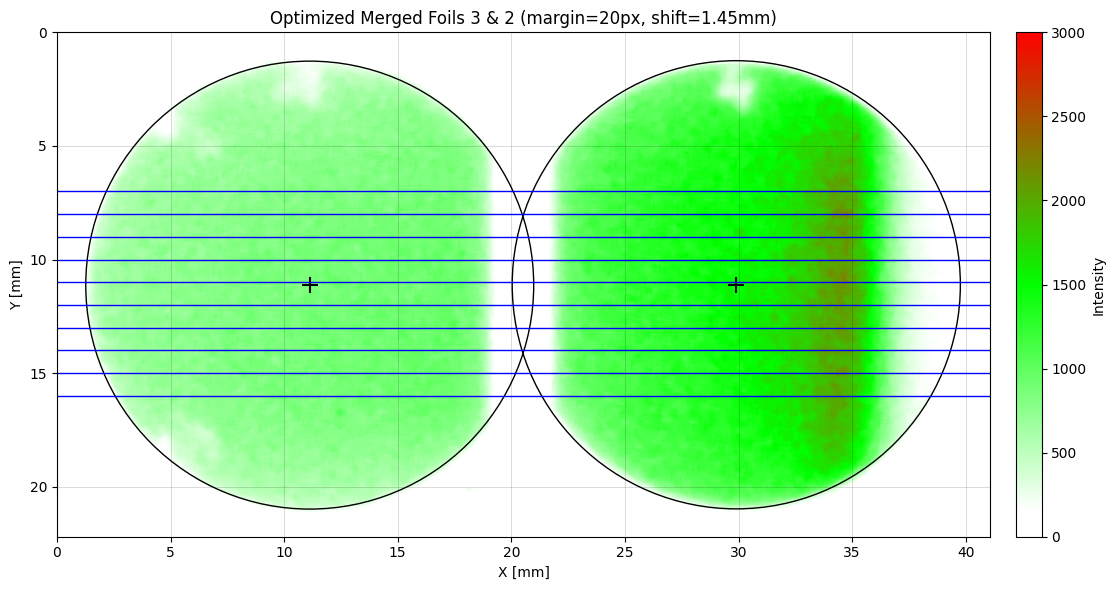

In [157]:
# Visualize optimized merged image
fig, ax = plt.subplots(figsize=(14, 6))

h_opt, w_opt = merged_image_opt.shape
extent_mm = [0, w_opt * PIXEL_SIZE_MM, h_opt * PIXEL_SIZE_MM, 0]

im = ax.imshow(merged_image_opt, cmap=CMAP, vmin=0, vmax=VMAX, extent=extent_mm)

# Circles and centers
for circle, label in [(left_circle_merged_opt, 'Left'), (right_circle_merged_opt, 'Right')]:
    cx_mm = circle.x * PIXEL_SIZE_MM
    cy_mm = circle.y * PIXEL_SIZE_MM
    r_mm = circle.r * PIXEL_SIZE_MM
    ax.add_patch(plt.Circle((cx_mm, cy_mm), r_mm, color='black', fill=False, lw=1))
    ax.plot(cx_mm, cy_mm, 'k+', ms=12, mew=1.5)

# Mark profile positions
for y_mm in profile_y_positions_mm:
    ax.axhline(y=y_mm, color='blue', linewidth=1)

ax.set_title(f'Optimized Merged Foils {LEFT_FOIL_ID} & {RIGHT_FOIL_ID} (margin={OPTIMIZED_MERGE_MARGIN}px, shift={optimal_shift:.2f}mm)')
ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')
ax.set_xticks(np.arange(0, w_opt * PIXEL_SIZE_MM + 1, 5))
ax.set_yticks(np.arange(0, h_opt * PIXEL_SIZE_MM + 1, 5))
ax.grid(True, color='k', alpha=0.2, lw=0.5)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Intensity')
plt.tight_layout()
plt.show()

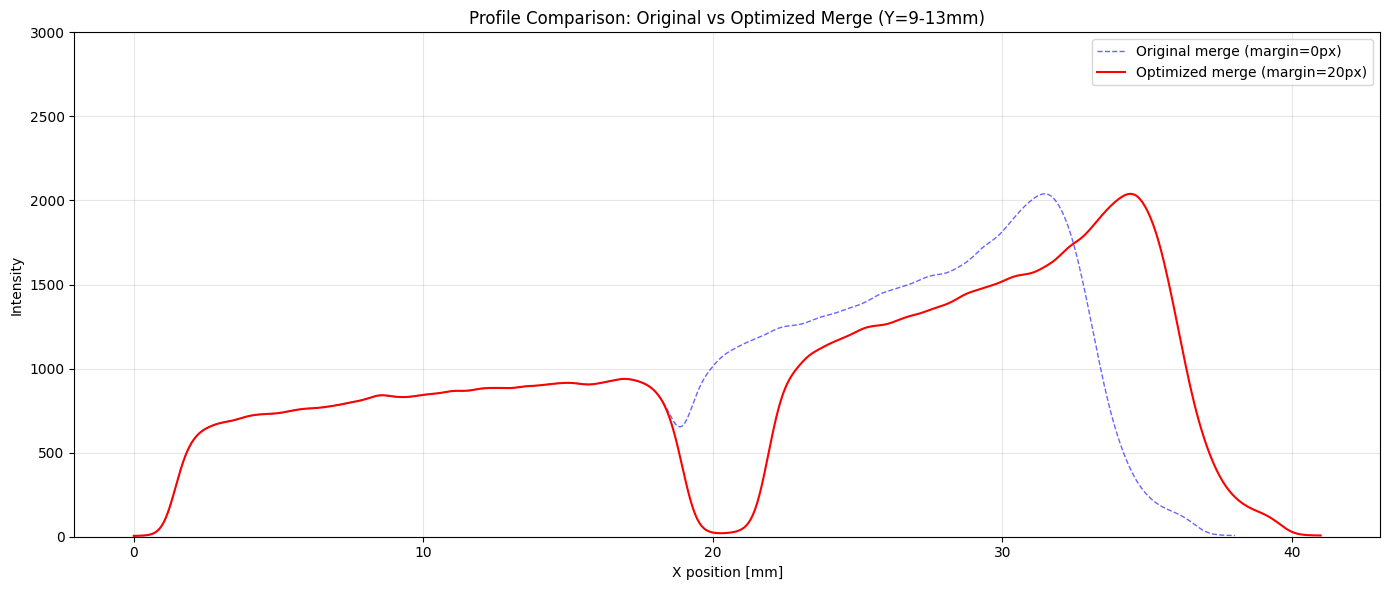

In [158]:
# Compare profiles: original vs optimized merge
fig, ax = plt.subplots(figsize=(14, 6))

# Original merged profile
x_mm_orig = np.arange(merged_image.shape[1]) * PIXEL_SIZE_MM
profile_orig = np.nanmean(merged_image[PROFILE_Y_MIN_PX:PROFILE_Y_MAX_PX, :].astype(float), axis=0)
profile_orig_smooth = gaussian_filter1d(profile_orig, sigma=SMOOTHING_SIGMA)

# Optimized merged profile  
x_mm_opt = np.arange(merged_image_opt.shape[1]) * PIXEL_SIZE_MM
profile_opt = np.nanmean(merged_image_opt[PROFILE_Y_MIN_PX:PROFILE_Y_MAX_PX, :].astype(float), axis=0)
profile_opt_smooth = gaussian_filter1d(profile_opt, sigma=SMOOTHING_SIGMA)

ax.plot(x_mm_orig, profile_orig_smooth, 'b--', lw=1, alpha=0.6, label=f'Original merge (margin={MERGE_MARGIN}px)')
ax.plot(x_mm_opt, profile_opt_smooth, 'r-', lw=1.5, label=f'Optimized merge (margin={OPTIMIZED_MERGE_MARGIN}px)')

ax.set(xlabel='X position [mm]', ylabel='Intensity', ylim=(0, VMAX),
       title=f'Profile Comparison: Original vs Optimized Merge (Y={PROFILE_Y_MIN_MM}-{PROFILE_Y_MAX_MM}mm)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save Results

In [159]:
# Save merged image data
output_path = DATA_PATH / f'merged_foils_{LEFT_FOIL_ID}_{RIGHT_FOIL_ID}.npz'

np.savez_compressed(
    output_path,
    merged_image=merged_image,
    left_circle_x=left_circle_merged.x,
    left_circle_y=left_circle_merged.y,
    left_circle_r=left_circle_merged.r,
    right_circle_x=right_circle_merged.x,
    right_circle_y=right_circle_merged.y,
    right_circle_r=right_circle_merged.r,
    merge_margin=MERGE_MARGIN,
    left_foil_id=LEFT_FOIL_ID,
    right_foil_id=RIGHT_FOIL_ID,
    pixel_size_mm=PIXEL_SIZE_MM

)
print(f"Saved to: {output_path}")


Saved to: C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_ccb\2025-12-19\merged_foils_3_2.npz
